In [1]:
import os
from pathlib import Path
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline


In [2]:
root_dir = r"/mnt/c/Users/deinf.janaelson/Documents/Datasets/"
dir_extracted = r"/mnt/c/Users/deinf.janaelson/Documents/Datasets/Extracted"


In [3]:
Path(dir_extracted).mkdir(parents=True, exist_ok=True)

In [4]:
def get_csv_files(dir):
    return [f for f in os.listdir(dir) if f.lower().endswith(".csv")]

In [5]:
files = get_csv_files(root_dir)

In [6]:
files

['disque100-2021-1.csv',
 'disque100-2021-2.csv',
 'disque100-2022-1.csv',
 'disque100-2022-2.csv',
 'disque100-2023-1.csv',
 'disque100-2023-2.csv',
 'disque100-2024-1.csv',
 'disque100-2024-2.csv',
 'disque100-2025-1.csv',
 'disque100-2025-2.csv']

In [ ]:
def load_dataset(csv_file, sep=";", encoding="utf-8"):
    return pd.read_csv(csv_file, sep=sep, encoding=encoding, low_memory=True)

In [ ]:
if dfs:
    del dfs

files = get_csv_files(root_dir)[:4]

dfs = []

for f in files:
    path = os.path.join(root_dir, f)
    
    for chunk in pd.read_csv(path, sep=";", encoding="utf-8", chunksize=10000):
        if 'violacao' in chunk.columns:
            dfs.append(chunk[chunk['violacao'].str.contains('tr[áa]fico', case=False, na=False)])

df_final = pd.concat(dfs, ignore_index=True)


In [54]:
import pandas as pd
import os
import logging
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

# =========================
# 🔧 CONFIG LOGGING
# =========================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(processName)s | %(message)s"
)

# =========================
# ⚙️ FUNÇÃO DE PROCESSAMENTO
# =========================
def process_file(path):
    import time
    import logging
    import pandas as pd
    import os

    start_time = time.time()
    filename = os.path.basename(path)

    try:
        dfs = []
        total_rows = 0
        matched_rows = 0

        for chunk in pd.read_csv(
            path,
            sep=";",
            encoding="utf-8",
            chunksize=50000   # ✅ mantém performance
        ):
            if "violacao" not in chunk.columns:
                continue

            total_rows += len(chunk)

            mask = chunk["violacao"].str.contains(
                r"tr[áa]fico",
                case=False,
                na=False,
                regex=True
            )

            count = mask.sum()
            matched_rows += count

            if count > 0:
                dfs.append(chunk.loc[mask])  # ✅ mantém TODAS as colunas

        elapsed = time.time() - start_time

        logging.info(
            f"{filename} | linhas: {total_rows:,} | matches: {matched_rows:,} | tempo: {elapsed:.2f}s"
        )

        if dfs:
            return pd.concat(dfs, ignore_index=True)

        return None

    except Exception as e:
        logging.error(f"Erro no arquivo {filename}: {e}")
        return None


# =========================
# 🚀 EXECUÇÃO PARALELA
# =========================
def run_parallel(root_dir, files):
    start_global = time.time()

    paths = [os.path.join(root_dir, f) for f in files]

    results = []

    with ProcessPoolExecutor() as executor:
        futures = [executor.submit(process_file, p) for p in paths]

        for f in tqdm(as_completed(futures), total=len(futures), desc="Processando arquivos"):
            result = f.result()
            if result is not None:
                results.append(result)

    df_final = pd.concat(results, ignore_index=True) if results else pd.DataFrame()

    total_time = time.time() - start_global

    logging.info("=" * 60)
    logging.info(f"TOTAL DE LINHAS RESULTADO: {len(df_final):,}")
    logging.info(f"TEMPO TOTAL: {total_time:.2f}s")
    logging.info("=" * 60)

    return df_final


# =========================
# ▶️ EXECUTAR
# =========================
df_final = run_parallel(root_dir, files)

Processando arquivos:   0%|          | 0/4 [00:00<?, ?it/s]/tmp/ipykernel_521138/1178320459.py:33: DtypeWarning: Columns (0: sl_vitima_naturalidade, 1: sl_vitima_naturalizado_uf, 2: sl_vitima_naturalizado_municipio, 3: Deficiência_relacionada_a_doença_rara, 4: Religião_da_vítima, 5: Etnia_da_vítima, 6: sl_suspeito_naturalidade, 7: sl_suspeito_naturalizado_uf, 8: sl_suspeito_naturalizado_municipio, 9: Deficiência_relacionada_a_doença_rara_suspeito, 10: suspeito_especificacao_etnia) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(
/tmp/ipykernel_521138/1178320459.py:33: DtypeWarning: Columns (0: sl_vitima_naturalidade, 1: sl_vitima_naturalizado_uf, 2: sl_vitima_naturalizado_municipio, 3: Deficiência_relacionada_a_doença_rara, 4: sl_suspeito_naturalidade, 5: sl_suspeito_naturalizado_uf, 6: sl_suspeito_naturalizado_municipio, 7: Deficiência_relacionada_a_doença_rara_suspeito) have mixed types. Specify dtype option on import or set low_me

In [55]:
df_final.shape

(280, 104)

In [48]:
from concurrent.futures import ProcessPoolExecutor
import pandas as pd
import os

def process_file(path):
    dfs = []
    
    for chunk in pd.read_csv(path, sep=";", encoding="utf-8", chunksize=50000):
        if "violacao" in chunk.columns:
            mask = chunk["violacao"].str.contains(r"tr[áa]fico", case=False, na=False)
            if mask.any():
                dfs.append(chunk.loc[mask])
    
    if dfs:
        return pd.concat(dfs)
    return None


paths = [os.path.join(root_dir, f) for f in files]

with ProcessPoolExecutor() as executor:
    results = list(executor.map(process_file, paths))

df_final2 = pd.concat([r for r in results if r is not None], ignore_index=True)

/tmp/ipykernel_521138/1947668787.py:8: DtypeWarning: Columns (0: sl_vitima_naturalidade, 1: sl_vitima_naturalizado_uf, 2: sl_vitima_naturalizado_municipio, 3: Deficiência_relacionada_a_doença_rara, 4: Religião_da_vítima, 5: Etnia_da_vítima, 6: sl_suspeito_naturalidade, 7: sl_suspeito_naturalizado_uf, 8: sl_suspeito_naturalizado_municipio, 9: Deficiência_relacionada_a_doença_rara_suspeito, 10: suspeito_especificacao_etnia) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, sep=";", encoding="utf-8", chunksize=50000):
/tmp/ipykernel_521138/1947668787.py:8: DtypeWarning: Columns (0: sl_vitima_naturalidade, 1: sl_vitima_naturalizado_uf, 2: sl_vitima_naturalizado_municipio, 3: Deficiência_relacionada_a_doença_rara, 4: sl_suspeito_naturalidade, 5: sl_suspeito_naturalizado_uf, 6: sl_suspeito_naturalizado_municipio, 7: Deficiência_relacionada_a_doença_rara_suspeito) have mixed types. Specify dtype option on import or set low_memory=False.

In [49]:
df_final2.shape

(280, 104)

In [41]:
df5 = df4[df4['violacao'].str.contains('tr[áa]fico', case=False, na=False, regex=True)]
df5.shape

(118, 62)

In [37]:
df1 = load_dataset(os.path.join(root_dir, files[0]))
df2 = load_dataset(os.path.join(root_dir, files[1]))

In [11]:
df2.shape

AttributeError: 'TextFileReader' object has no attribute 'shape'

In [ ]:
def filter_terms(df, cols=[], term=""):
    return df[cols].str.contains(term, na=False, case=False)


In [ ]:
df1[filter_terms(df1, ['violacao'], 'tráfico|trafico')]

In [ ]:
df1.shape

In [ ]:
filter_trafficking = df1['violacao'].str.contains('tráfico', na=False, case=False)
filter_trafficking = df1['violacao'].str.contains('tráfico', na=False, case=False)

In [ ]:
# df[filter_trafficking].to_csv(os.path.join(dir_extracted, files[0]))
df[filter_trafficking].head()

,hash,Data de cadastro,Canal de atendimento,Denúncia emergencial,Denunciante,Cenário da violação,País,UF,Município,Frequência,...,Grau de instrução do suspeito,Religião do suspeito,Raça\Cor do suspeito,Suspeito Etnia,Faixa de renda do suspeito,Vínculo Órgão\PJ do suspeito,sl_suspeito_ramo,suspeito_especificacao_etnia,vitima_especificacao_etnia,violacao
1803,6fa1ed73ec4c3f385683c9fc03a3c062,12/01/2021 07:34,TELEFÔNICO,NÃO,ANÔNIMO,CASA DA VÍTIMA,BRASIL,SP,SÃO PAULO,DIARIAMENTE,...,N/D,N/D,PRETA,N/D,N/D,NaN,N/D,N/D,N/D,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESS...
2488,79c48e0d422d3ab1a306f8d7e498b8be,08/01/2021 23:11,TELEFÔNICO,NÃO,ANÔNIMO,SERVIÇO DE ABRIGAMENTO,BRASIL,SP,SÃO BERNARDO DO CAMPO,DIARIAMENTE,...,N/D,N/D,N/D,N/D,N/D,NaN,N/D,N/D,N/D,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESS...
4663,ba12fedf0ff1a3bbe12b853e0ae2da65,13/01/2021 02:28,TELEFÔNICO,NÃO,ANÔNIMO,CASA ONDE RESIDE A VÍTIMA E O SUSPEITO,BRASIL,SP,SÃO PAULO,DIARIAMENTE,...,N/D,N/D,N/D,N/D,N/D,NaN,N/D,N/D,N/D,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESS...
5710,3feb5ed25d579fa7b6d499d5781e59ff,13/01/2021 15:52,TELEFÔNICO,NÃO,ANÔNIMO,CASA ONDE RESIDE A VÍTIMA E O SUSPEITO,BRASIL,SP,SÃO PAULO,SEMANALMENTE,...,N/D,N/D,PRETA,N/D,N/D,NaN,N/D,N/D,N/D,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESS...
6267,1b13f107009820e1bc2f357e81b77d58,05/01/2021 08:28,CARTA,N/D,TERCEIRO,VIA PÚBLICA,BRASIL,RJ,RIO DE JANEIRO,DIARIAMENTE,...,N/D,N/D,N/D,N/D,N/D,NaN,N/D,N/D,N/D,LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESS...


In [ ]:
humamn_trafficking_files = get_csv_files(dir_extracted)

In [ ]:
dfs = [load_dataset(os.path.join(dir_extracted, f)) for f in humamn_trafficking_files]

In [ ]:
df_ht = pd.concat(dfs, axis=0)

In [ ]:
df_ht.shape

(1789, 109)

In [ ]:
filter_ht = df_ht.violacao.str.contains("tráfico", na=False, case=False)
df_ht[filter_ht]['data'].value_counts()

violacao
LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE CRIANÇAS - NACIONAL         524
LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESSOAS - NACIONAL          381
LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE PESSOAS - INTERNACIONAL     372
LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE CRIANÇAS - INTERNACIONAL    185
LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE MULHERES - INTERNACIONAL    118
LIBERDADE>DIREITOS INDIVIDUAIS>TRÁFICO DE MULHERES - NACIONAL          93
Name: count, dtype: int64

## Carregados violações de tráfico de pessoas extraídas dos conjuntos de dados

In [ ]:
import re
import unicodedata

def normalize_columns(columns):
    def normalize(col):
        # 1. strip
        col = col.strip()
                
        # col = re.sub(r'(Nenhum nome de coluna)')

        # 2. remover acentos
        col = unicodedata.normalize('NFKD', col)
        col = ''.join(c for c in col if not unicodedata.combining(c))

        # 3. substituir especiais por "_"
        col = re.sub(r'[()\?\\\/\-]', '_', col)

        # 4. substituir espaços por "_"
        col = re.sub(r'\s+', '_', col)

        # 5. remover múltiplos "_"
        col = re.sub(r'_+', '_', col)

        # ✅ 6. remover QUALQUER coisa no final que não seja letra ou número
        col = re.sub(r'[^a-zA-Z0-9]+$', '', col)

        col = col.strip()

        # 7. minúsculo
        col = col.lower()

        return col

    return [normalize(c) for c in columns]

In [ ]:
files_extracted = get_csv_files(dir_extracted)

In [ ]:
del df
dfs = []
for f in files_extracted:
    df_temp = load_dataset(os.path.join(dir_extracted, f))
    dfs.append(df_temp)
df = pd.concat(dfs, axis=0, ignore_index=True)
df.shape

(1673, 62)

## Verificação de inconsistências nas colunas

In [ ]:
for i in range(9):
    print(set(dfs[i+1].columns) - set(dfs[i].columns))

set()
set()
set()
set()
set()
set()
set()
set()
set()


In [ ]:
import os
import pandas as pd

root_dir = "/mnt/c/Users/deinf.janaelson/Documents/Datasets/Extracted"

arquivos = [
    os.path.join(root_dir, f)
    for f in os.listdir(root_dir)
    if f.endswith(".csv")
]

colunas_por_arquivo = {}

for arq in arquivos:
    df_temp = pd.read_csv(arq, sep=";", nrows=0)
    colunas_por_arquivo[arq] = set(df_temp.columns)

# união de todas
todas_colunas = set().union(*colunas_por_arquivo.values())

# interseção
colunas_comuns = set.intersection(*colunas_por_arquivo.values())

print("Total colunas únicas:", len(todas_colunas))
print("Colunas comuns:", len(colunas_comuns))
print()

print("Colunas extras (diferenças):")
for col in sorted(todas_colunas - colunas_comuns):
    print(col)


Total colunas únicas: 62
Colunas comuns: 62

Colunas extras (diferenças):


### Extração da subespécie de violação: tráfico humano

In [ ]:
df['violacao'] =df['violacao'].apply(lambda x: x.split(">")[2])

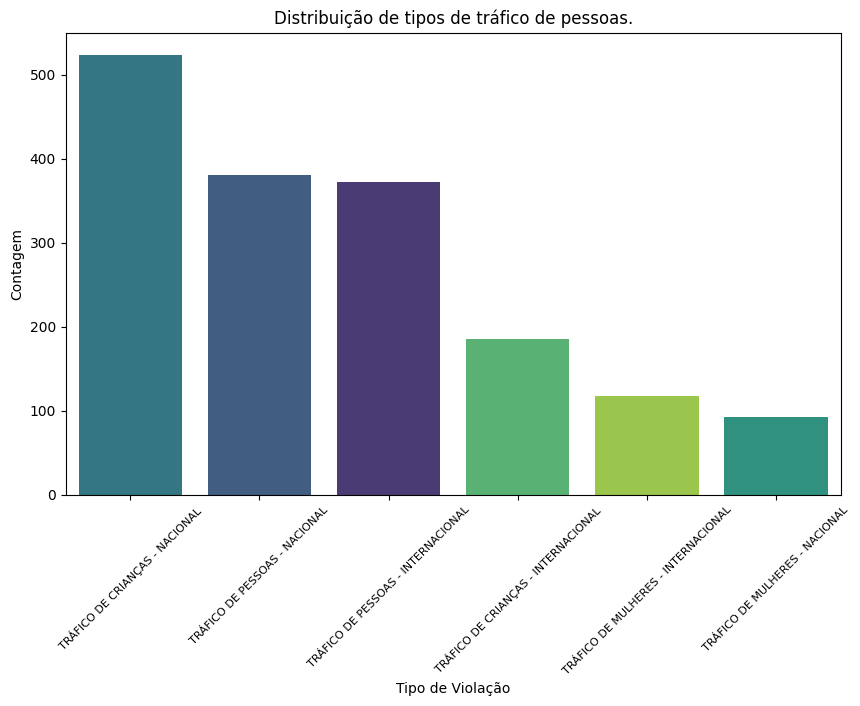

In [ ]:
plt.figure(figsize=(10,6))
plt.title("Distribuição de tipos de tráfico de pessoas.")
order = df['violacao'].value_counts().index
sns.countplot(df, x='violacao', order=order,palette='viridis', hue='violacao')
plt.xlabel("Tipo de Violação")
plt.ylabel("Contagem")
plt.xticks(rotation=45, fontsize=8)
plt.show()

/tmp/ipykernel_5476/555347413.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


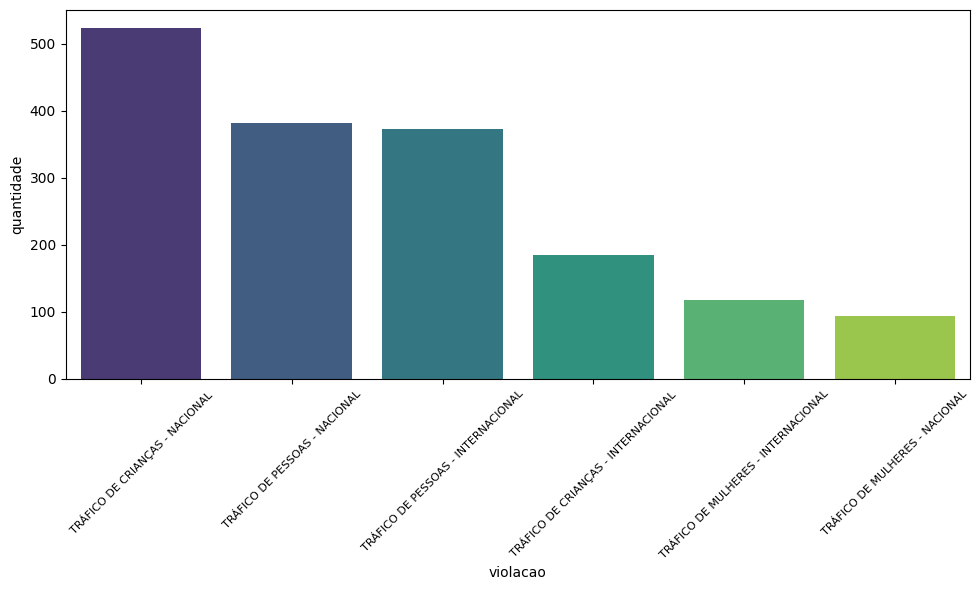

In [ ]:

counts = df['violacao'].value_counts().reset_index()
counts.columns = ['violacao', 'quantidade']

plt.figure(figsize=(10,6))
sns.barplot(
    data=counts,
    x='violacao',
    y='quantidade',
    palette='viridis'
)

plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()


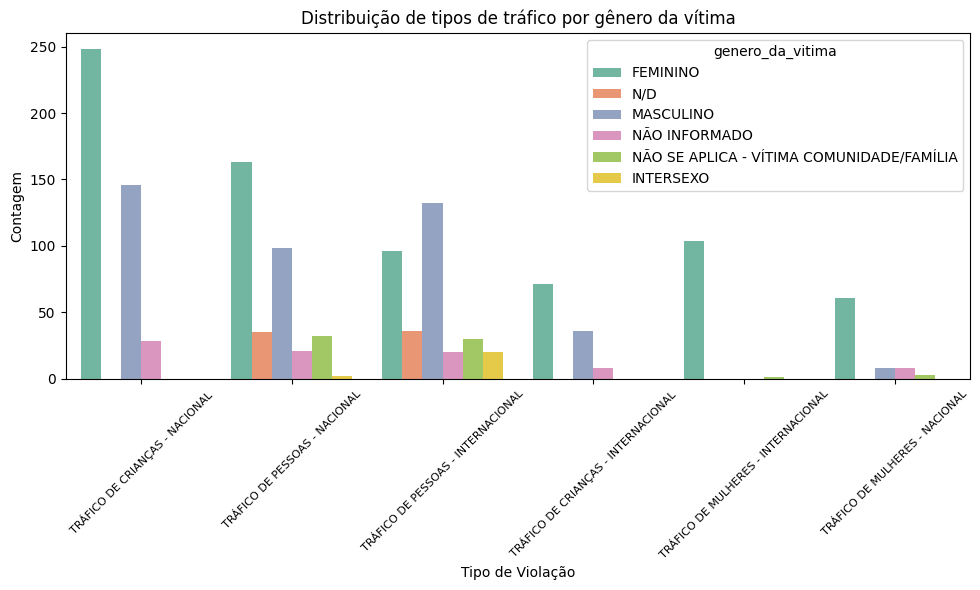

In [ ]:
plt.figure(figsize=(10,6))

order = df['violacao'].value_counts().index

sns.countplot(
    data=df,
    x='violacao',
    order=order,
    hue='genero_da_vitima',
    palette='Set2'
)

plt.title("Distribuição de tipos de tráfico por gênero da vítima")
plt.xlabel("Tipo de Violação")
plt.ylabel("Contagem")

plt.xticks(rotation=45, fontsize=8)

plt.tight_layout()
plt.show()



### Avaliação temporal

In [ ]:
df['data_de_cadastro'] = pd.to_datetime(df['data_de_cadastro'], errors='coerce')

In [ ]:
df['ano'] = df['data_de_cadastro'].dt.year

df['semestre'] = df['data_de_cadastro'].dt.month.apply(
    lambda m: 1 if m <= 6 else 2
)


In [ ]:
df['periodo'] = df['ano'].astype(str) + "-" + df['semestre'].astype(str)

In [ ]:
df_group = (
    df.groupby(['periodo', 'violacao'])
    .size()
    .reset_index(name='quantidade')
)

In [ ]:
df_group['periodo_ordem'] = pd.to_datetime(
    df_group['periodo'].str.replace(
        r'-(1|2)',
        lambda x: '-01' if x.group(1) == '1' else '-07',
        regex=True
    )
)

df_group = df_group.sort_values('periodo_ordem')

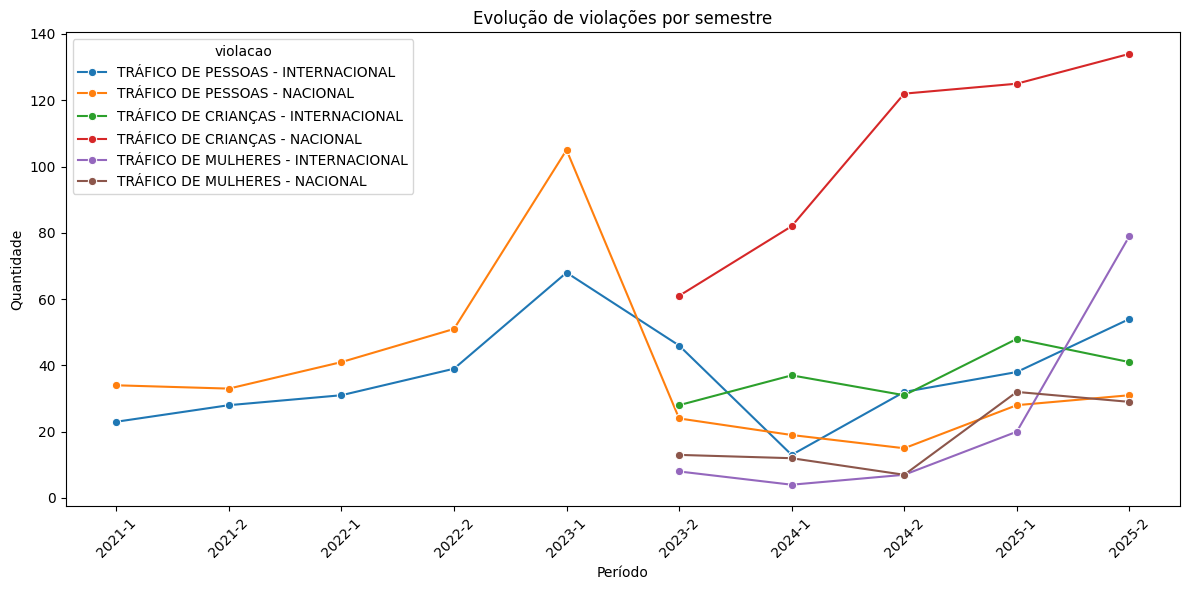

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_group,
    x='periodo',
    y='quantidade',
    hue='violacao',
    marker='o'
)

plt.title("Evolução de violações por semestre")
plt.xlabel("Período")
plt.ylabel("Quantidade")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

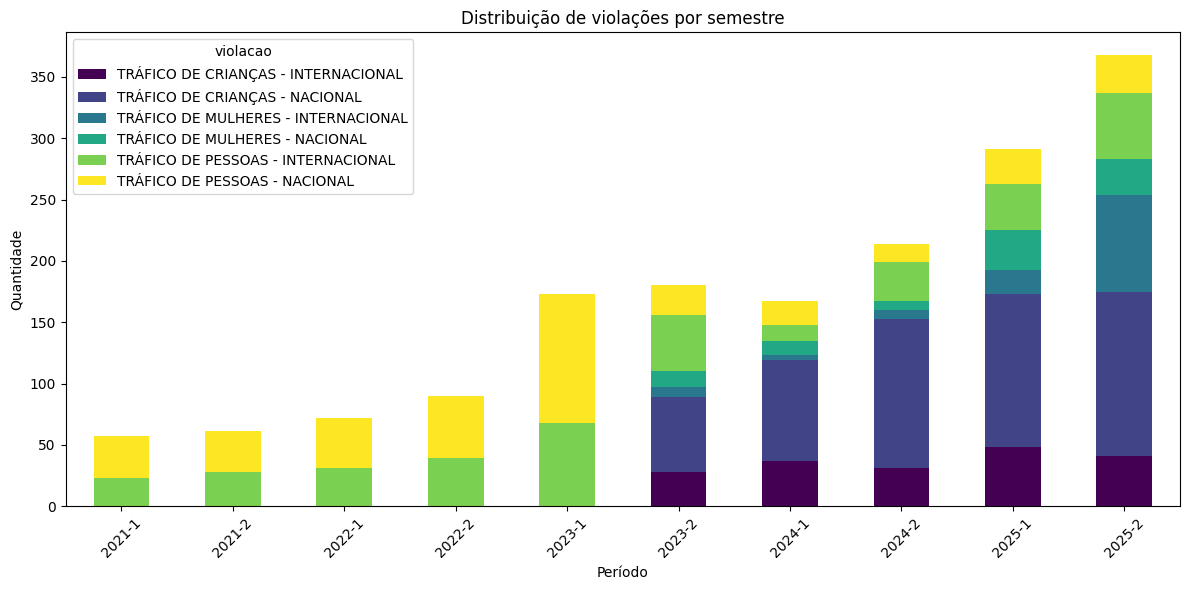

In [ ]:
pivot = df_group.pivot_table(
    index='periodo',
    columns='violacao',
    values='quantidade',
    fill_value=0
)

pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='viridis'
)

plt.title("Distribuição de violações por semestre")
plt.xlabel("Período")
plt.ylabel("Quantidade")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
top = df['violacao'].value_counts().head(5).index
df_group = df_group[df_group['violacao'].isin(top)]

In [ ]:
df['data_de_cadastro'] = pd.to_datetime(df['data_de_cadastro'], errors='coerce')

df['ano_mes'] = df['data_de_cadastro'].dt.to_period('M').astype(str)

In [ ]:
df_mes = (
    df.groupby(['ano_mes', 'violacao'])
    .size()
    .reset_index(name='quantidade')
)

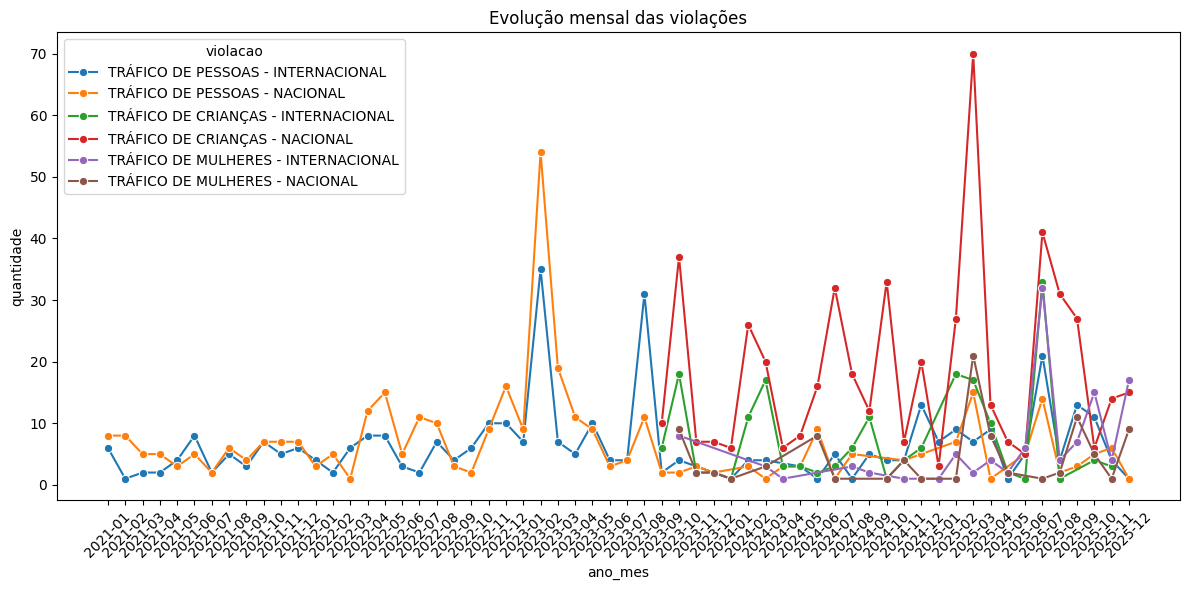

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_mes,
    x='ano_mes',
    y='quantidade',
    hue='violacao',
    marker='o'
)

plt.xticks(rotation=45)
plt.title("Evolução mensal das violações")
plt.tight_layout()
plt.show()

In [ ]:
df_total = (
    df.groupby('ano_mes')
    .size()
    .reset_index(name='quantidade')
)

df_total['crescimento_%'] = df_total['quantidade'].pct_change() * 100

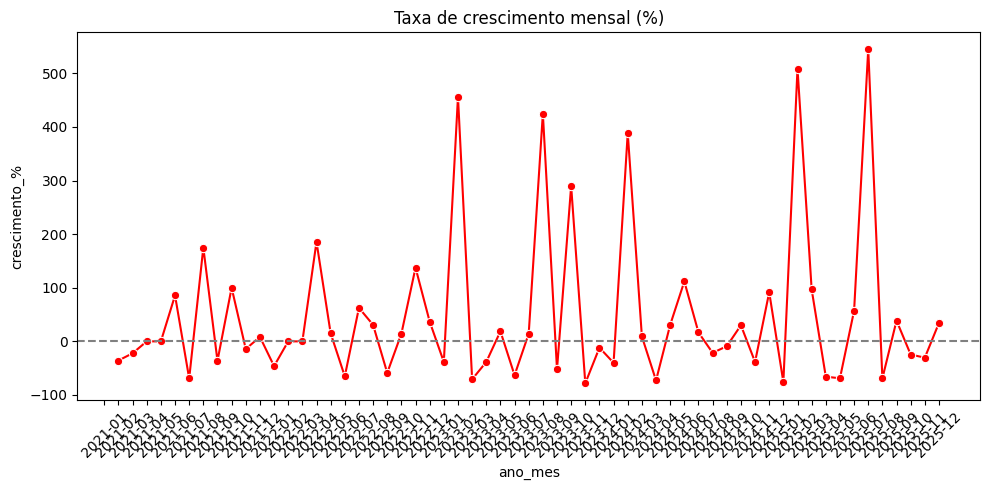

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df_total,
    x='ano_mes',
    y='crescimento_%',
    marker='o',
    color='red'
)

plt.axhline(0, linestyle='--', color='gray')

plt.title("Taxa de crescimento mensal (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_gen = (
    df.groupby(['ano_mes', 'genero_da_vitima'])
    .size()
    .reset_index(name='quantidade')
)


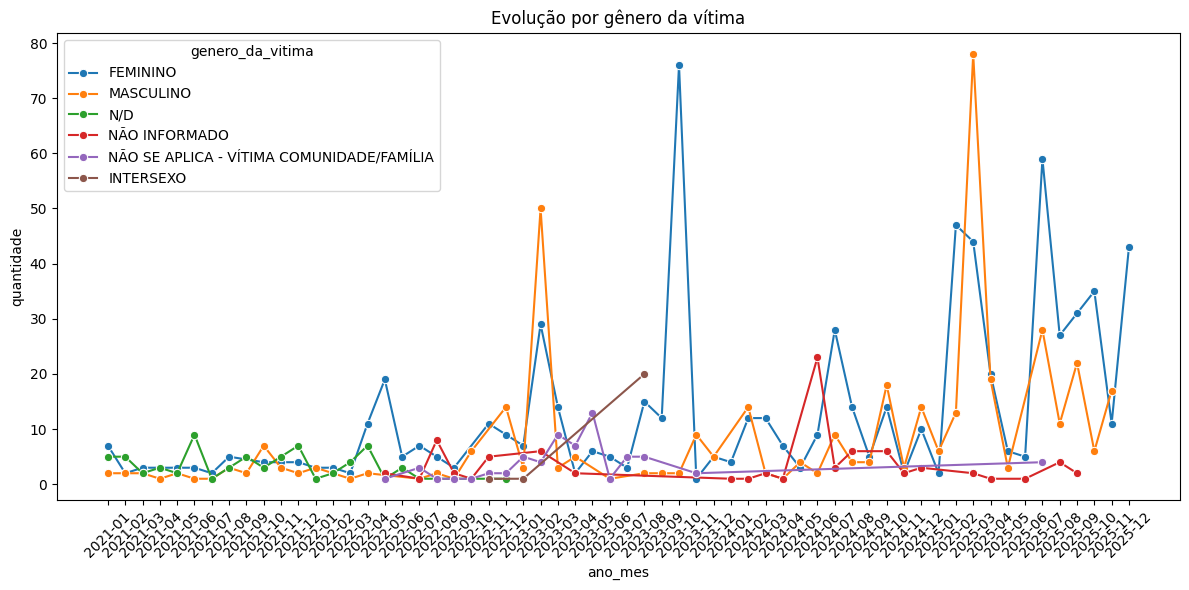

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_gen,
    x='ano_mes',
    y='quantidade',
    hue='genero_da_vitima',
    marker='o'
)

plt.title("Evolução por gênero da vítima")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

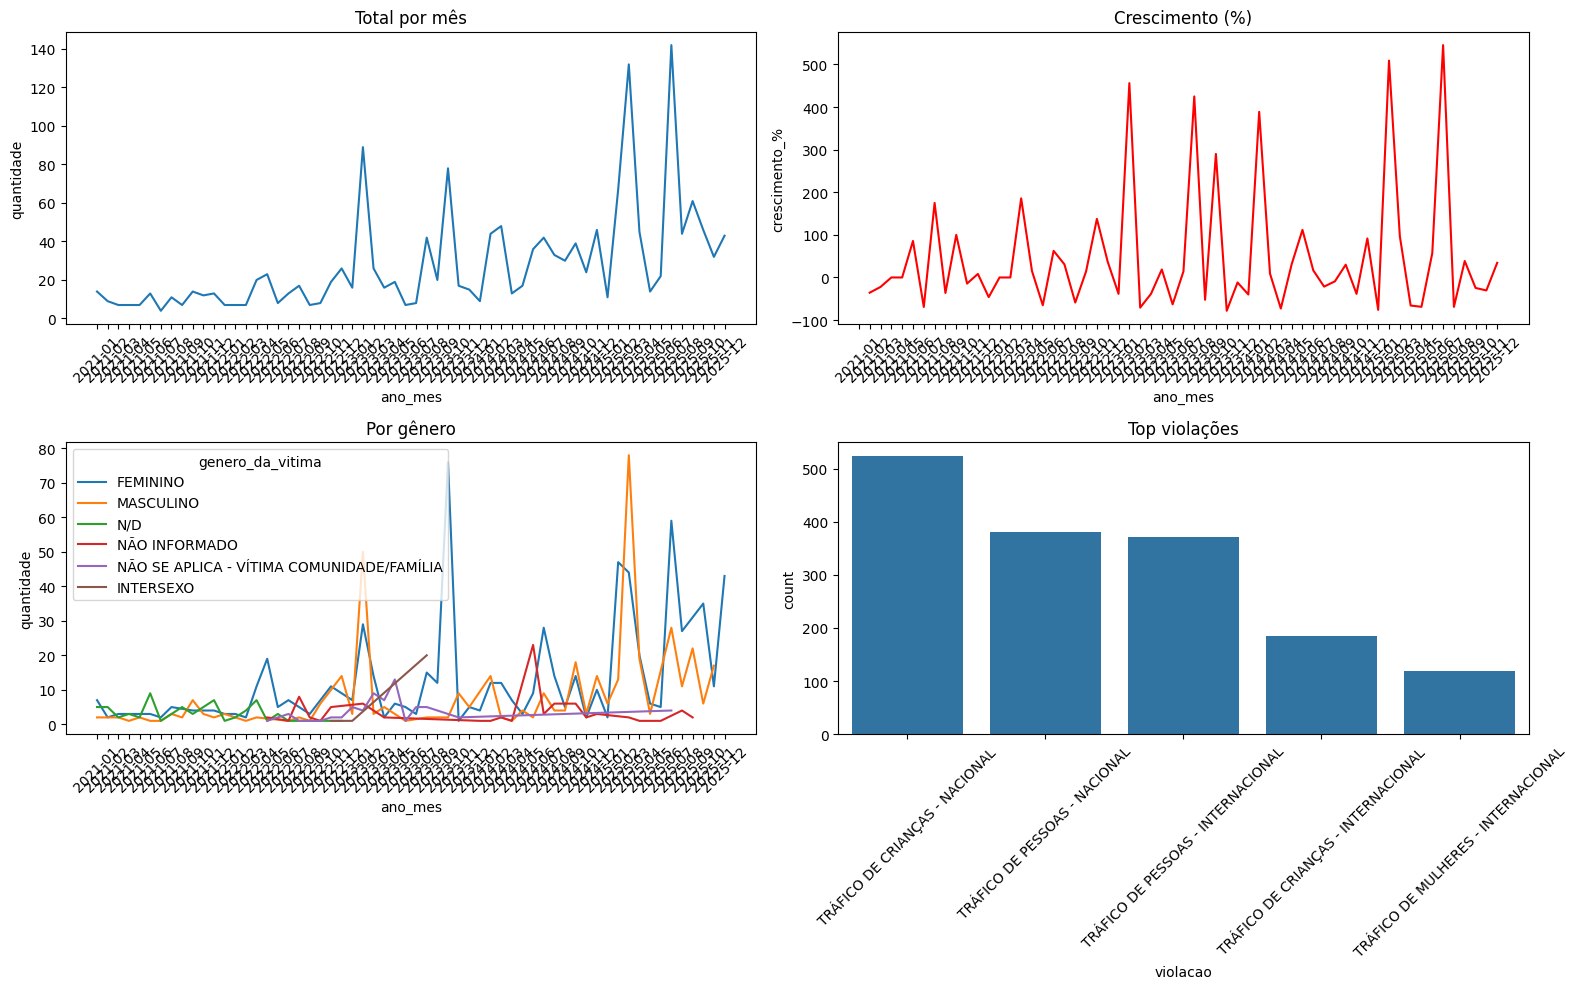

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# 1. Total por mês
sns.lineplot(data=df_total, x='ano_mes', y='quantidade', ax=axes[0,0])
axes[0,0].set_title("Total por mês")

# 2. Crescimento
sns.lineplot(data=df_total, x='ano_mes', y='crescimento_%', ax=axes[0,1], color='red')
axes[0,1].set_title("Crescimento (%)")

# 3. Por gênero
sns.lineplot(data=df_gen, x='ano_mes', y='quantidade', hue='genero_da_vitima', ax=axes[1,0])
axes[1,0].set_title("Por gênero")

# 4. Top violações
top = df['violacao'].value_counts().head(5).index
df_top = df[df['violacao'].isin(top)]

sns.countplot(data=df_top, x='violacao', ax=axes[1,1], order=top)
axes[1,1].set_title("Top violações")

for ax in axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

fig = px.line(
    df_mes,
    x='ano_mes',
    y='quantidade',
    color='violacao',
    title='Evolução mensal interativa'
)

fig.show()

ModuleNotFoundError: No module named 'plotly'

In [ ]:
px.line(
    df[df['genero_da_vitima'] == 'feminino'],
    x='ano_mes',
    y=df.groupby('ano_mes').size().values
)

In [ ]:
top_violacoes = df['violacao'].value_counts().head(5).index

df_filtrado = df[df['violacao'].isin(top_violacoes)]

In [ ]:
df_uf = (
    df_filtrado
    .groupby(['uf', 'genero_da_vitima', 'violacao'])
    .size()
    .reset_index(name='quantidade')
)

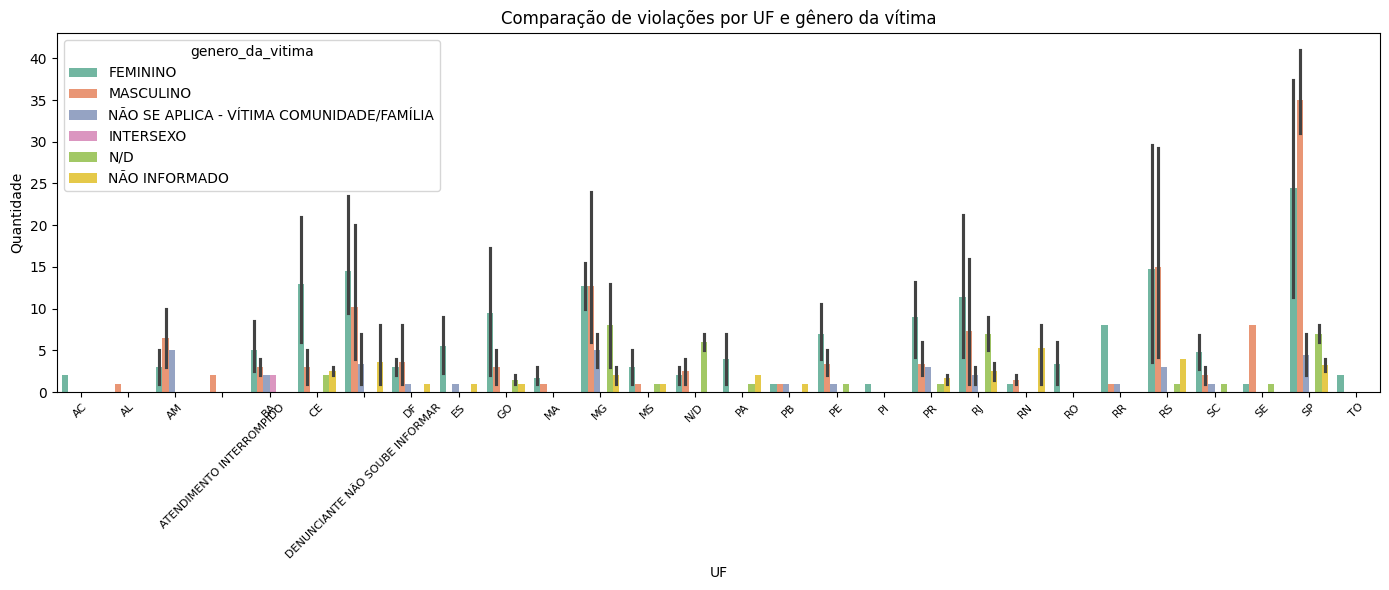

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.barplot(
    data=df_uf,
    x='uf',
    y='quantidade',
    hue='genero_da_vitima',
    palette='Set2'
)

plt.title("Comparação de violações por UF e gênero da vítima")
plt.xlabel("UF")
plt.ylabel("Quantidade")

plt.xticks(rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

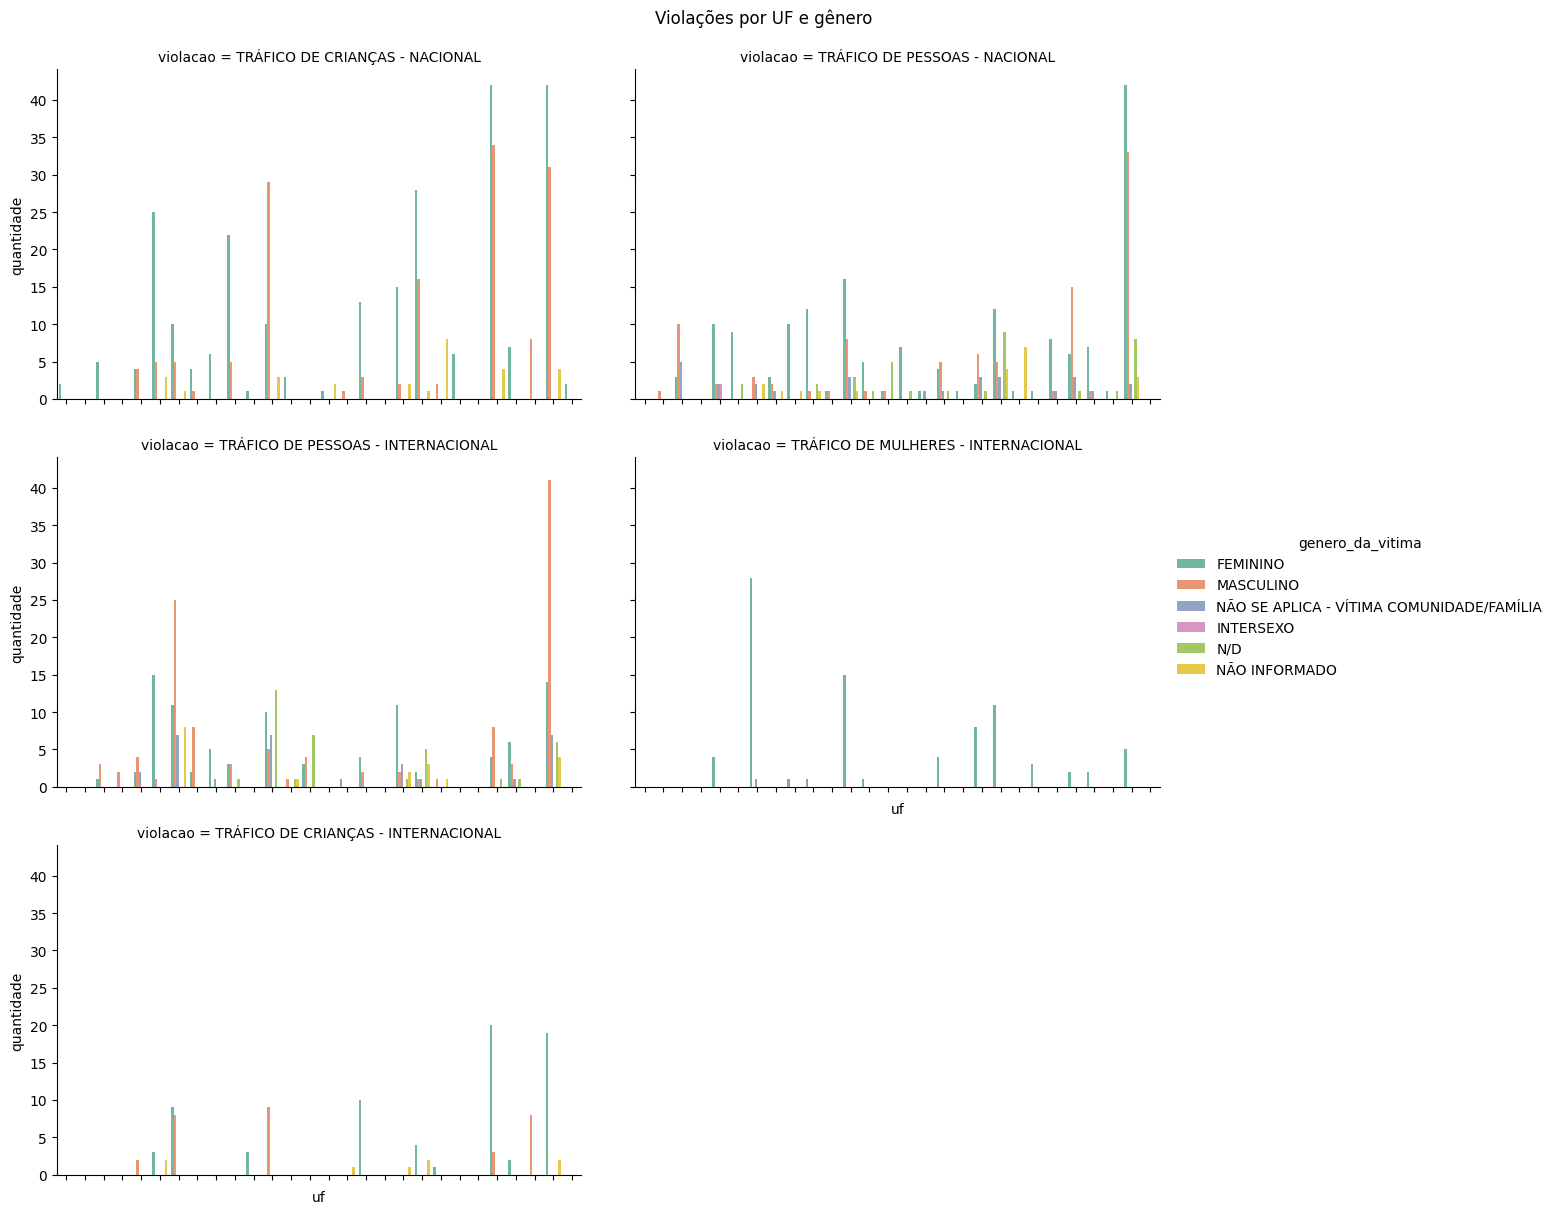

In [ ]:
g = sns.catplot(
    data=df_uf,
    kind='bar',
    x='uf',
    y='quantidade',
    hue='genero_da_vitima',
    col='violacao',
    col_wrap=2,
    height=4,
    aspect=1.5,
    palette='Set2'
)

g.set_xticklabels(rotation=45)
g.fig.suptitle("Violações por UF e gênero", y=1.02)

plt.show()

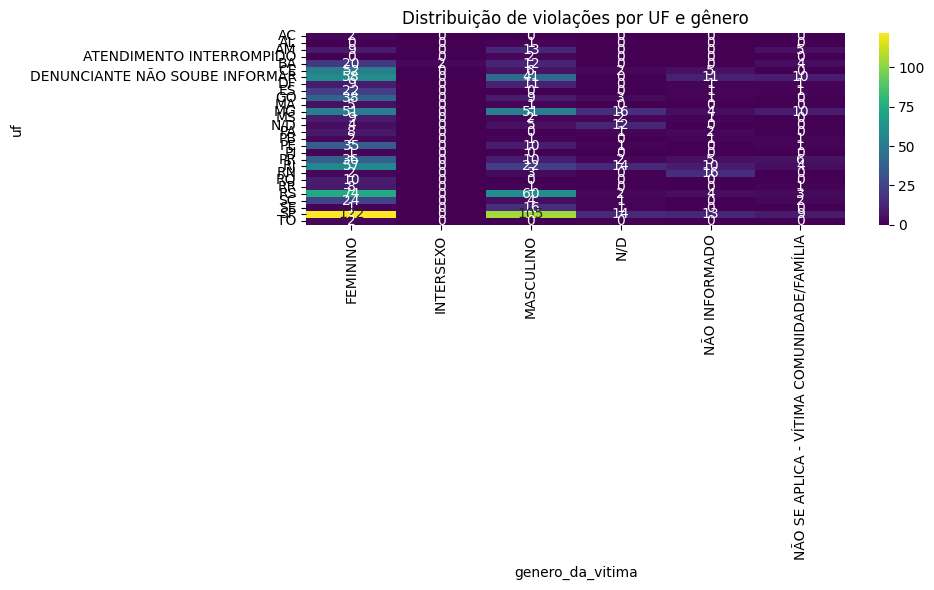

In [ ]:
pivot = df_uf.pivot_table(
    index='uf',
    columns='genero_da_vitima',
    values='quantidade',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    cmap='viridis',
    annot=True,
    fmt='d'
)

plt.title("Distribuição de violações por UF e gênero")
plt.tight_layout()
plt.show()

<Axes: xlabel='genero_da_vitima', ylabel='uf'>

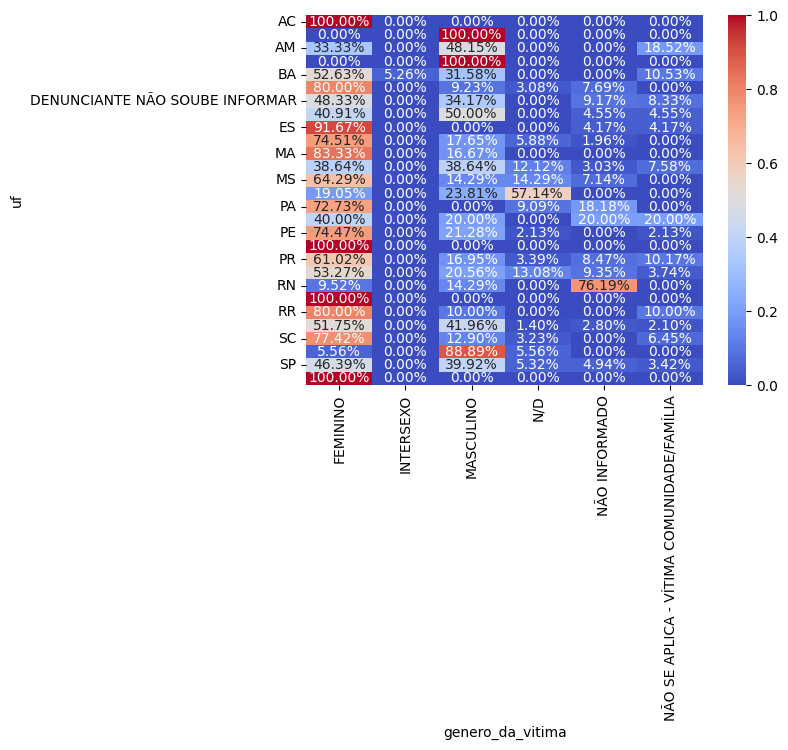

In [ ]:
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

sns.heatmap(
    pivot_pct,
    cmap='coolwarm',
    annot=True,
    fmt='.2%'
)

<Axes: xlabel='uf', ylabel='quantidade'>

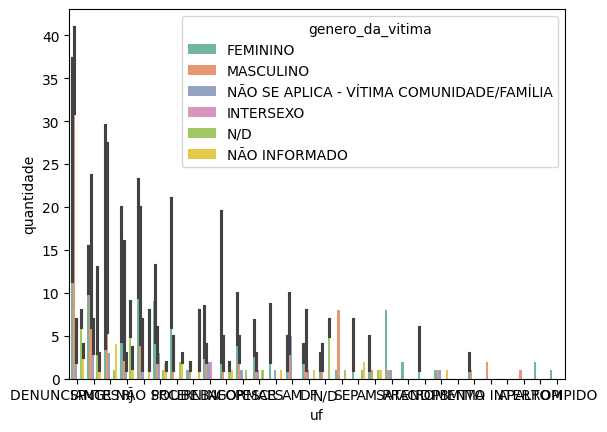

In [ ]:
ordem_uf = df.groupby('uf').size().sort_values(ascending=False).index

sns.barplot(
    data=df_uf,
    x='uf',
    y='quantidade',
    hue='genero_da_vitima',
    order=ordem_uf,
    palette='Set2'
)